In [5]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"   # 解决 Mac M4 内核崩溃问题
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'    # 限制服务器上只用 0,1 号卡

import sys
import numpy as np 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

# 2. 智能识别设备（此时服务器上的 cuda:0 实际对应的就是物理上的 0 号卡）
if torch.cuda.is_available():
    device = torch.device("cuda:0") 
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"代码自动识别并连接到了: {device}")


代码自动识别并连接到了: mps


In [7]:
from torchvision import datasets
raw_train = datasets.CIFAR10(
    root="data/cifar10_raw",
    train=True,
    download=True
)

100.0%


In [10]:
raw_test = datasets.CIFAR10(
    root="data/cifar10_raw",
    train=False,
    download=True
)
print("Raw train size:", len(raw_train))
print("Raw test size:", len(raw_test))
print(raw_train.classes)
image, label = raw_train[0]
print("Image type:", type(image))
print("Image size:", image.size)
print("Label index:", label)
print("Class name:", raw_train.classes[label])

Raw train size: 50000
Raw test size: 10000
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Image type: <class 'PIL.Image.Image'>
Image size: (32, 32)
Label index: 6
Class name: frog


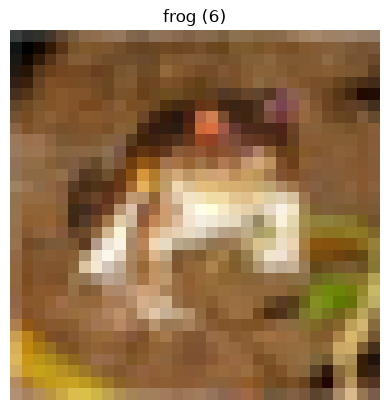

In [11]:
import matplotlib.pyplot as plt
plt.imshow(image)
plt.title(
    f"{raw_train.classes[label]} ({label})"
)
plt.axis("off")
plt.show()

In [12]:
import torch
train_targets = torch.tensor(
    raw_train.targets
)
class_counts = torch.bincount(
    train_targets,
    minlength=len(raw_train.classes)
)

for class_name, count in zip(
    raw_train.classes,
    class_counts
):
    print(class_name, count.item())

airplane 5000
automobile 5000
bird 5000
cat 5000
deer 5000
dog 5000
frog 5000
horse 5000
ship 5000
truck 5000
